In [ ]:
!pip install -q ir-datasets datasets transformers torch torchmetrics pyarrow fastparquet tqdm

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 93.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set this to your actual folder in Drive
PROJECT_ROOT = '/content/drive/MyDrive/EpistemicRanker'

import os
os.chdir(PROJECT_ROOT)

Mounted at /content/drive


In [ ]:
# !cd ..
# !cd drive
!pwd
!ls

/content/drive/MyDrive/EpistemicRanker
checkpoints  data  EpicRanker_v2.ipynb	reports


In [ ]:
import os

dirs = [
    f"{PROJECT_ROOT}/data/raw",
    f"{PROJECT_ROOT}/data/processed",
    f"{PROJECT_ROOT}/reports/phase2",
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f"Created: {d}")

Created: /content/drive/MyDrive/EpistemicRanker/data/raw
Created: /content/drive/MyDrive/EpistemicRanker/data/processed
Created: /content/drive/MyDrive/EpistemicRanker/reports/phase2


In [ ]:
# ── Option A: upload parquet files from your local machine ───────────────────
# Uncomment the block below if files are not yet in Drive.
#
# from google.colab import files
# import shutil
# print("Select train_pairs.parquet, test_4bucket.parquet, ood_slice.parquet")
# uploaded = files.upload()
# for fname in uploaded:
#     dst = f"{PROJECT_ROOT}/data/processed/{fname}"
#     shutil.move(fname, dst)
#     print(f"  Moved → {dst}")

# ── Option B: verify files already in Drive ───────────────────────────────────
required = ["train_pairs.parquet", "ood_slice.parquet"]
optional = ["test_4bucket.parquet"]   # rebuilt automatically if missing

for fname in required + optional:
    path = f"{PROJECT_ROOT}/data/processed/{fname}"
    tag  = "✓" if os.path.exists(path) else ("✗ MISSING (required)" if fname in required else "– will be rebuilt")
    print(f"  {tag}  {fname}")


  ✓  train_pairs.parquet
  ✓  ood_slice.parquet
  ✓  test_4bucket.parquet


#

In [ ]:
# ── Colab config — all paths and hardware-specific settings live here ─────────
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/EpistemicRanker')
DATA_DIR     = PROJECT_ROOT / 'data'
PROCESSED    = DATA_DIR / 'processed'
REPORTS_DIR  = PROJECT_ROOT / 'reports' / 'phase2'
CKPT_DIR     = PROJECT_ROOT / 'checkpoints'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Model / training
NUM_CLASSES      = 2
MAX_LENGTH       = 128
EPOCHS           = 5

# ── Tune BATCH_SIZE to your GPU ───────────────────────────────────────────────
# A100 (40 GB) → 128   T4 (15 GB) → 32   V100/L4 → 64
BATCH_SIZE       = 128   # quads; each quad = 4 seqs → 512 seqs/step on A100
NUM_WORKERS      = 4     # Colab Pro supports multiprocessing

# Optimizer — layerwise LR decay (FIX-7)
LR_HEAD    = 5e-4
LR_LAYER11 = 1e-5
LR_LAYER10 = 5e-6
LR_LAYER9  = 1e-6
WEIGHT_DECAY = 1e-3

# Loss hyper-params
LABEL_SMOOTH_EPS = 0.02
OOD_EXPOSE_EVERY = 3
OOD_LOSS_WEIGHT  = 0.5
KL_WEIGHT        = 0.4
S_REG_WEIGHT     = 0.01
S_TARGET         = 10.0

# Per-sample weights (FIX-5)
PAIR_WEIGHTS = {'positive': 4.0, 'hard_negative': 2.0, 'easy_negative': 0.5}

# Device
import torch
device = torch.device('cuda')
print(f"✓ Config loaded | device={device} | batch={BATCH_SIZE} quads ({BATCH_SIZE*4} seqs/step)")


✓ Config loaded | device=cuda | batch=128 quads (512 seqs/step)


In [ ]:
import os, json, random, time, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, set_seed
print("✓ Imports OK")


✓ Imports OK


In [ ]:
# ── EpicRankerQuadDataset ─────────────────────────────────────────────────────
class EpicRankerQuadDataset(Dataset):
    """
    In-distribution only (positive / hard_negative / easy_negative).
    One index = one query quad of 4 rows in canonical 1:1:2 order.
    OOD rows are stripped on load — they share query_id=-1 and would
    collapse into a single group of 4 repeated samples (FIX-1).
    """
    TYPE_ORDER = ['positive', 'hard_negative', 'easy_negative', 'easy_negative']

    def __init__(self, parquet_path, tokenizer, max_length=128):
        df = pd.read_parquet(parquet_path)
        self.df         = df[df['pair_type'] != 'ood'].copy().reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.grouped    = self.df.groupby('query_id')
        self.query_ids  = list(self.grouped.groups.keys())
        counts = self.df['pair_type'].value_counts().to_dict()
        print(f'[QuadDataset] {Path(parquet_path).name}: {counts}')

    def __len__(self):
        return len(self.query_ids)

    def _get_row_for_type(self, group_df, pair_type):
        subset = group_df[group_df['pair_type'] == pair_type]
        return subset.iloc[0] if len(subset) > 0 else group_df.iloc[-1]

    def __getitem__(self, idx):
        qid      = self.query_ids[idx]
        group_df = self.grouped.get_group(qid)
        seen_easy, rows = 0, []
        for t in self.TYPE_ORDER:
            if t == 'easy_negative':
                easy_rows = group_df[group_df['pair_type'] == 'easy_negative']
                rows.append(easy_rows.iloc[seen_easy] if len(easy_rows) > seen_easy
                            else group_df.iloc[-1])
                seen_easy += 1
            else:
                rows.append(self._get_row_for_type(group_df, t))

        quad_df = pd.DataFrame(rows)
        enc = self.tokenizer(
            quad_df['query_text'].tolist(), quad_df['passage_text'].tolist(),
            padding='max_length', truncation=True, max_length=self.max_length,
            return_tensors='pt', return_token_type_ids=True,
        )
        return {
            'input_ids':      enc['input_ids'],
            'attention_mask': enc['attention_mask'],
            'token_type_ids': enc['token_type_ids'],
            'labels':         torch.tensor(quad_df['label'].astype(int).values,
                                           dtype=torch.long),
            'pair_types':     quad_df['pair_type'].tolist(),
        }


# ── OodFlatDataset ─────────────────────────────────────────────────────────────
class OodFlatDataset(Dataset):
    """
    FIX-1: Flat loader for OOD rows — no query_id grouping.
    Each row is one independent sample.
    """
    def __init__(self, parquet_path, tokenizer, max_length=128):
        df = pd.read_parquet(parquet_path)
        if 'pair_type' in df.columns:
            df = df[df['pair_type'] == 'ood'].copy().reset_index(drop=True)
        self.passages   = df['passage_text'].fillna('').astype(str).tolist()
        self.queries    = (df['query_text'].fillna('').astype(str).tolist()
                           if 'query_text' in df.columns
                           else [''] * len(self.passages))
        self.pair_types = (df['pair_type'].tolist()
                           if 'pair_type' in df.columns
                           else ['ood'] * len(self.passages))
        self.tokenizer  = tokenizer
        self.max_length = max_length
        print(f'[OodFlatDataset] {Path(parquet_path).name}: {len(self.passages)} OOD rows')

    def __len__(self):
        return len(self.passages)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.queries[idx], self.passages[idx],
            padding='max_length', truncation=True, max_length=self.max_length,
            return_tensors='pt', return_token_type_ids=True,
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'pair_types':     self.pair_types[idx],
        }


# ── Collate functions ──────────────────────────────────────────────────────────
def collate_quads(batch):
    return {
        'input_ids':      torch.cat([b['input_ids']      for b in batch], dim=0),
        'attention_mask': torch.cat([b['attention_mask']  for b in batch], dim=0),
        'token_type_ids': torch.cat([b['token_type_ids']  for b in batch], dim=0),
        'labels':         torch.cat([b['labels']          for b in batch], dim=0),
        'pair_types':     [pt for b in batch for pt in b['pair_types']],
    }

def collate_flat(batch):
    return {
        'input_ids':      torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask']  for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids']  for b in batch]),
        'pair_types':     [b['pair_types'] for b in batch],
    }

print('✓ Dataset classes defined')


✓ Dataset classes defined


In [ ]:
def ensure_phase2_inputs():
    """
    FIX-2: use train_pairs.parquet (not train_pairs_clean.parquet).
    FIX-1: OOD rows in test_4bucket get unique negative query_ids.
    """
    train_path = PROCESSED / 'train_pairs.parquet'
    test_path  = PROCESSED / 'test_4bucket.parquet'
    ood_path   = PROCESSED / 'ood_slice.parquet'

    missing = [p for p in [train_path, ood_path] if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f'Missing required files: {[str(p) for p in missing]}. '
            'Upload them to Drive first (see Cell 4).'
        )

    if not test_path.exists():
        print(f'Rebuilding {test_path.name}...')
        df_pairs = pd.read_parquet(train_path)
        df_ood   = pd.read_parquet(ood_path)
        for frame in (df_pairs, df_ood):
            for col in ('query_text', 'passage_text'):
                if col in frame.columns:
                    frame[col] = frame[col].fillna('').astype(str)
            if 'passage_id' in frame.columns:
                frame['passage_id'] = frame['passage_id'].astype(str)
            if 'pair_type' in frame.columns:
                frame['pair_type'] = frame['pair_type'].astype(str)

        indist_sample = (df_pairs[df_pairs['pair_type'] != 'ood']
                         .groupby('pair_type', group_keys=False).head(500))
        ood_sample = df_ood.head(500).copy()
        # FIX-1: unique query_ids so OOD rows are never collapsed
        ood_sample['query_id'] = range(-1, -len(ood_sample) - 1, -1)

        test_4bucket = pd.concat([indist_sample, ood_sample], ignore_index=True)
        test_4bucket.to_parquet(test_path, index=False, compression='snappy')
        print(f'  Created: {test_4bucket["pair_type"].value_counts().to_dict()}')

    print(f'✓ Input files verified')
    return train_path, test_path, ood_path

train_path, test_path, ood_path = ensure_phase2_inputs()


✓ Input files verified


In [ ]:
class EvidentialHead(nn.Module):
    def __init__(self, input_dim=768, num_classes=2):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
        self.register_buffer('temperature', torch.ones(1))

    def set_temperature(self, temp):
        if temp <= 0: raise ValueError('temperature must be > 0')
        self.temperature.fill_(float(temp))

    def forward(self, features, temp=None):
        t        = temp if temp is not None else self.temperature
        evidence = F.softplus(self.linear(features) / t)
        return evidence, evidence + 1.0


class BertWithEvidentialHead(nn.Module):
    """BERT Cross-Encoder with binary Evidential head. (FIX-7: token_type_ids)"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained('bert-base-uncased')
        for p in self.bert.parameters():
            p.requires_grad = False
        self.bert.eval()
        self.head = EvidentialHead(768, num_classes)

    def forward(self, input_ids=None, attention_mask=None,
                token_type_ids=None, temp=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                            token_type_ids=token_type_ids, **kwargs)
        return self.head(outputs.last_hidden_state[:, 0, :], temp=temp)

print('✓ Model classes defined')


✓ Model classes defined


In [ ]:
def get_expected_probs(alpha):
    return alpha / alpha.sum(dim=1, keepdim=True).clamp_min(1e-12)

def get_smoothed_one_hot(labels, num_classes=2, epsilon=0.02):
    one_hot = torch.zeros(labels.size(0), num_classes, device=labels.device)
    one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
    return (1 - epsilon) * one_hot + (epsilon / num_classes)

def brier_score_loss(alpha, target_or_onehot, num_classes=2, sample_weights=None):
    """FIX-5: accepts per-sample weights to counterbalance 1:1:2 gradient imbalance."""
    p_hat = get_expected_probs(alpha)
    if target_or_onehot.dim() == 1:
        one_hot = torch.zeros(target_or_onehot.size(0), num_classes,
                              device=target_or_onehot.device)
        one_hot.scatter_(1, target_or_onehot.unsqueeze(1), 1.0)
    else:
        one_hot = target_or_onehot
    per_sample = torch.sum((p_hat - one_hot) ** 2, dim=1)
    if sample_weights is not None:
        per_sample = per_sample * sample_weights
    return per_sample.mean()

def binary_kl_penalty(alpha, labels, eps=1e-12):
    """Binary KL: penalise only the one incorrect class."""
    one_hot    = F.one_hot(labels, num_classes=NUM_CLASSES).float()
    wrong_mask = 1.0 - one_hot
    beta       = one_hot + wrong_mask * alpha
    S_beta     = beta.sum(dim=1, keepdim=True).clamp_min(eps)
    term1 = torch.lgamma(S_beta) - torch.lgamma(
                torch.tensor(float(NUM_CLASSES), device=alpha.device))
    term2 = -torch.sum(torch.lgamma(beta.clamp_min(eps)), dim=1, keepdim=True)
    term3 = torch.sum((beta - 1.0) * (torch.digamma(beta.clamp_min(eps))
                                       - torch.digamma(S_beta)), dim=1, keepdim=True)
    return (term1 + term2 + term3).mean()

def s_regularisation_loss(alpha, pair_types, s_target=S_TARGET):
    """FIX-6: squared-hinge cap on easy_negative total strength."""
    easy_mask = torch.tensor([pt == 'easy_negative' for pt in pair_types],
                              dtype=torch.bool, device=alpha.device)
    if not easy_mask.any():
        return torch.tensor(0.0, device=alpha.device)
    return F.relu(alpha[easy_mask].sum(dim=1) - s_target).pow(2).mean()

def vacuity_loss_fn(ood_alpha):
    """FIX-3: target S=K=2 via squared-error. Previous: ood_alpha.mean() (too weak)."""
    return (ood_alpha.sum(dim=1) - NUM_CLASSES).pow(2).mean()

print('✓ Loss functions defined')


✓ Loss functions defined


In [ ]:
def base_accuracy(alpha, target):
    return (torch.argmax(get_expected_probs(alpha), dim=1) == target).float().mean()

def eru_mutual_information(alpha, eps=1e-12):
    S        = alpha.sum(dim=1, keepdim=True).clamp_min(eps)
    p_mean   = alpha / S
    pred_ent = -torch.sum(p_mean * torch.log(p_mean.clamp_min(eps)), dim=1)
    exp_ent  = -torch.sum((alpha / S) * (torch.digamma(alpha + 1)
                           - torch.digamma(S + 1)), dim=1)
    return pred_ent - exp_ent

def _ece_from_probs(probs, target, n_bins=15):
    conf, preds = probs.max(dim=1)
    acc  = preds.eq(target).float()
    bins = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    ece  = torch.zeros(1, device=probs.device)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask   = (conf >= lo) & (conf <= hi if i == n_bins - 1 else conf < hi)
        if mask.any():
            ece += mask.float().mean() * (conf[mask].mean() - acc[mask].mean()).abs()
    return ece.squeeze(0)

def profile_uncertainty(all_alphas, all_pair_types):
    """
    Groups Dirichlet S by pair_type.
    Expected after all fixes:
      easy_negative ≈ positive >> hard_negative >> ood ≈ 2.0
    """
    profiles = {k: [] for k in ('positive', 'hard_negative', 'easy_negative', 'ood')}
    S = all_alphas.sum(dim=1)
    for i, pt in enumerate(all_pair_types):
        if pt in profiles:
            profiles[pt].append(S[i].item())
    print('\n--- Phase 2 Uncertainty Profiles (Mean Strength S) ---')
    results = {}
    for pt, vals in profiles.items():
        if vals:
            mean_s = sum(vals) / len(vals)
            results[pt] = round(mean_s, 4)
            print(f'  {pt.capitalize():>15}: {mean_s:.4f}  (n={len(vals)})')
        else:
            results[pt] = None
            print(f'  {pt.capitalize():>15}: no samples')
    return results

print('✓ Metrics + profiling defined')


✓ Metrics + profiling defined


In [ ]:
def get_ood_batch(ood_iter, ood_loader):
    try:
        batch = next(ood_iter)
    except StopIteration:
        ood_iter = iter(ood_loader)
        batch    = next(ood_iter)
    return batch, ood_iter

def quick_gradient_check(model):
    model.train()
    ids  = torch.randint(0, 30522, (4, MAX_LENGTH), device=device)
    mask = torch.ones_like(ids)
    tids = torch.zeros_like(ids)
    tgt  = torch.randint(0, NUM_CLASSES, (4,), device=device)
    _, alpha = model(input_ids=ids, attention_mask=mask, token_type_ids=tids)
    loss = brier_score_loss(alpha, tgt, num_classes=NUM_CLASSES)
    assert torch.isfinite(loss), 'Loss is NaN/Inf'
    model.zero_grad()
    loss.backward()
    head_grads = [p.grad for p in model.head.parameters() if p.requires_grad]
    assert all(g is not None for g in head_grads), 'No gradients on head'
    assert all(torch.isfinite(g).all() for g in head_grads), 'NaN/Inf in grads'
    print('✓ Gradient check passed')

print('✓ Helpers defined')


✓ Helpers defined


In [ ]:
set_seed(42)
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# In-distribution (quad structure)
train_ds = EpicRankerQuadDataset(train_path, tokenizer, MAX_LENGTH)
test_ds  = EpicRankerQuadDataset(test_path,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_quads,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_quads,
                          pin_memory=True)

# FIX-1: dedicated flat OOD loaders
ood_train_ds = OodFlatDataset(ood_path,  tokenizer, MAX_LENGTH)
ood_eval_ds  = OodFlatDataset(test_path, tokenizer, MAX_LENGTH)

ood_train_loader = DataLoader(ood_train_ds, batch_size=BATCH_SIZE * 4,
                               shuffle=True,  num_workers=NUM_WORKERS,
                               collate_fn=collate_flat, pin_memory=True)
ood_eval_loader  = DataLoader(ood_eval_ds,  batch_size=BATCH_SIZE * 4,
                               shuffle=False, num_workers=NUM_WORKERS,
                               collate_fn=collate_flat, pin_memory=True)
ood_iter = iter(ood_train_loader)

# Model — FIX-7: unfreeze layers 9–11 with layerwise LR decay
model = BertWithEvidentialHead(num_classes=NUM_CLASSES).to(device)
for layer_idx in (9, 10, 11):
    for p in model.bert.encoder.layer[layer_idx].parameters():
        p.requires_grad = True
    model.bert.encoder.layer[layer_idx].train()
model.head.set_temperature(1.0)
quick_gradient_check(model)

optimizer = optim.AdamW([
    {'params': model.head.parameters(),                   'lr': LR_HEAD},
    {'params': model.bert.encoder.layer[11].parameters(), 'lr': LR_LAYER11},
    {'params': model.bert.encoder.layer[10].parameters(), 'lr': LR_LAYER10},
    {'params': model.bert.encoder.layer[9].parameters(),  'lr': LR_LAYER9},
], weight_decay=WEIGHT_DECAY)

scaler = GradScaler()   # Mixed precision — free speed on A100
print(f'✓ Model ready | trainable params: '
      f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Gradient check passed
✓ Model ready | trainable params: 21,265,154


/tmp/ipykernel_736/2007695807.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()   # Mixed precision — free speed on A100


In [ ]:
train_losses, val_accs, epoch_times = [], [], []

print(f'--- Phase 2 Training | {EPOCHS} epochs | {BATCH_SIZE} quads ({BATCH_SIZE*4} seqs/step) ---')
print(f'    Unfrozen BERT layers : 9, 10, 11')
print(f'    Loss weights         : pos={PAIR_WEIGHTS["positive"]} '
      f'hard={PAIR_WEIGHTS["hard_negative"]} easy={PAIR_WEIGHTS["easy_negative"]}')

for epoch in range(1, EPOCHS + 1):
    model.train()
    for layer_idx in (9, 10, 11):
        model.bert.encoder.layer[layer_idx].train()

    total_loss, total_count, batch_idx = 0.0, 0, 0
    epoch_start = time.time()

    for batch in train_loader:
        batch_idx  += 1
        input_ids   = batch['input_ids'].to(device, non_blocking=True)
        attn_mask   = batch['attention_mask'].to(device, non_blocking=True)
        token_tids  = batch['token_type_ids'].to(device, non_blocking=True)
        labels      = batch['labels'].to(device, non_blocking=True)
        pair_types  = batch['pair_types']

        one_hot = get_smoothed_one_hot(labels, NUM_CLASSES, LABEL_SMOOTH_EPS)

        # Forward under mixed precision (FIX-4: in-distribution only)
        with autocast():
            outputs = model.bert(input_ids=input_ids, attention_mask=attn_mask,
                                 token_type_ids=token_tids)
            cls = outputs.last_hidden_state[:, 0, :]
            _, alpha = model.head(cls)

            # FIX-5: per-sample weights
            sample_weights = torch.tensor(
                [PAIR_WEIGHTS.get(pt, 1.0) for pt in pair_types],
                dtype=torch.float32, device=device)

            brier_loss = brier_score_loss(alpha, one_hot, NUM_CLASSES, sample_weights)
            kl_loss    = binary_kl_penalty(alpha, labels)
            s_reg      = s_regularisation_loss(alpha, pair_types, S_TARGET)  # FIX-6
            loss       = brier_loss + KL_WEIGHT * kl_loss + S_REG_WEIGHT * s_reg

        # FIX-3 & FIX-4: OOD vacuity — separate forward, no Brier/KL
        if batch_idx % OOD_EXPOSE_EVERY == 0:
            ood_batch, ood_iter = get_ood_batch(ood_iter, ood_train_loader)
            with autocast():
                _, ood_alpha = model(
                    input_ids=ood_batch['input_ids'].to(device, non_blocking=True),
                    attention_mask=ood_batch['attention_mask'].to(device, non_blocking=True),
                    token_type_ids=ood_batch['token_type_ids'].to(device, non_blocking=True),
                )
            loss = loss + OOD_LOSS_WEIGHT * vacuity_loss_fn(ood_alpha)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        total_loss  += loss.item() * labels.size(0)
        total_count += labels.size(0)

    epoch_time = time.time() - epoch_start

    # Validation
    model.eval()
    va_list, vl_list = [], []
    with torch.no_grad():
        for batch in test_loader:
            with autocast():
                _, alpha = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    token_type_ids=batch['token_type_ids'].to(device),
                )
            va_list.append(alpha)
            vl_list.append(batch['labels'].to(device))

    val_acc = base_accuracy(torch.cat(va_list), torch.cat(vl_list)).item()
    train_losses.append(total_loss / total_count)
    val_accs.append(val_acc)
    epoch_times.append(epoch_time)

    print(f'Epoch {epoch}/{EPOCHS} | Loss: {train_losses[-1]:.4f} | '
          f'Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s')

    # Save checkpoint to Drive after every epoch
    ckpt_path = CKPT_DIR / f'phase2_epoch{epoch}.pt'
    torch.save(model.state_dict(), ckpt_path)
    print(f'  Checkpoint → {ckpt_path}')


--- Phase 2 Training | 5 epochs | 128 quads (512 seqs/step) ---
    Unfrozen BERT layers : 9, 10, 11
    Loss weights         : pos=4.0 hard=2.0 easy=0.5


/tmp/ipykernel_736/2505447099.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_736/2505447099.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_736/2505447099.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | Loss: 0.4072 | Val Acc: 0.7704 | Time: 85.5s
  Checkpoint → /content/drive/MyDrive/EpistemicRanker/checkpoints/phase2_epoch1.pt
Epoch 2/5 | Loss: 0.3083 | Val Acc: 0.7844 | Time: 83.5s
  Checkpoint → /content/drive/MyDrive/EpistemicRanker/checkpoints/phase2_epoch2.pt
Epoch 3/5 | Loss: 0.2907 | Val Acc: 0.8124 | Time: 83.5s
  Checkpoint → /content/drive/MyDrive/EpistemicRanker/checkpoints/phase2_epoch3.pt
Epoch 4/5 | Loss: 0.2791 | Val Acc: 0.8124 | Time: 83.4s
  Checkpoint → /content/drive/MyDrive/EpistemicRanker/checkpoints/phase2_epoch4.pt
Epoch 5/5 | Loss: 0.2702 | Val Acc: 0.8111 | Time: 83.7s
  Checkpoint → /content/drive/MyDrive/EpistemicRanker/checkpoints/phase2_epoch5.pt


In [ ]:
print('\n--- Full Phase 2 Metric Suite ---')
model.eval()

# In-distribution
all_alphas_indist, all_labels_indist, all_pair_types_indist = [], [], []
with torch.no_grad():
    for batch in test_loader:
        with autocast():
            _, alpha = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                token_type_ids=batch['token_type_ids'].to(device),
            )
        all_alphas_indist.append(alpha)
        all_labels_indist.append(batch['labels'].to(device))
        all_pair_types_indist.extend(batch['pair_types'])

alpha_indist  = torch.cat(all_alphas_indist)
labels_indist = torch.cat(all_labels_indist)

# FIX-1: OOD via flat loader — all 500 samples (not 4)
all_alphas_ood, all_pair_types_ood = [], []
with torch.no_grad():
    for batch in ood_eval_loader:
        with autocast():
            _, alpha = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                token_type_ids=batch['token_type_ids'].to(device),
            )
        all_alphas_ood.append(alpha)
        all_pair_types_ood.extend(batch['pair_types'])

alpha_ood = torch.cat(all_alphas_ood)

clean_acc    = base_accuracy(alpha_indist, labels_indist).item()
clean_brier  = brier_score_loss(alpha_indist, labels_indist, NUM_CLASSES).item()
clean_ece    = _ece_from_probs(get_expected_probs(alpha_indist), labels_indist).item()
clean_eru    = eru_mutual_information(alpha_indist).mean().item()
mean_S_clean = alpha_indist.sum(dim=1).mean().item()
mean_S_ood   = alpha_ood.sum(dim=1).mean().item()

print(f'\n1. Predictive Performance')
print(f'   Accuracy : {clean_acc:.4f}')
print(f'   Brier    : {clean_brier:.4f}')
print(f'   ECE      : {clean_ece:.4f}')

print(f'\n2. Epistemic Uncertainty')
print(f'   ERU / MI       : {clean_eru:.4f}')
print(f'   Mean S (clean) : {mean_S_clean:.2f}')
print(f'   Mean S (OOD)   : {mean_S_ood:.2f}  (n={len(all_pair_types_ood)})')

all_alphas_combined    = torch.cat([alpha_indist, alpha_ood])
all_pair_types_combined = all_pair_types_indist + all_pair_types_ood
uncertainty_profiles   = profile_uncertainty(all_alphas_combined, all_pair_types_combined)

s_ratio = uncertainty_profiles["ood"] / uncertainty_profiles["hard_negative"]
# Target: < 0.4 (OOD should be well below hard_neg)
# Current: 2.003 / 5.602 = 0.357  ← good
print(f"OOD/HardNeg S-ratio: {s_ratio:.3f}  (target < 0.40)")

# Also add the positive/hard_neg gap as a routing margin metric
routing_margin = uncertainty_profiles["positive"] - uncertainty_profiles["hard_negative"]
print(f"Routing margin (pos - hard_neg): {routing_margin:.3f}  (target > 3.0)")
# Current: 6.884 - 5.602 = 1.282  ← too narrow, needs improvement

results = {
    'accuracy': round(clean_acc, 4), 'brier': round(clean_brier, 4),
    'ece': round(clean_ece, 4),      'eru_mi': round(clean_eru, 4),
    'mean_S_clean': round(mean_S_clean, 4),
    'mean_S_ood':   round(mean_S_ood, 4),
    'ood_eval_n':   len(all_pair_types_ood),
    'uncertainty_profiles': uncertainty_profiles,
    'train_losses': train_losses, 'val_accs': val_accs, 'epoch_times': epoch_times,
}
out_path = REPORTS_DIR / 'phase2_results.json'
out_path.write_text(json.dumps(results, indent=2))
print(f'\n✓ Results saved → {out_path}')



--- Full Phase 2 Metric Suite ---


/tmp/ipykernel_736/1312916334.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_736/1312916334.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



1. Predictive Performance
   Accuracy : 0.8111
   Brier    : 0.2500
   ECE      : 0.0489

2. Epistemic Uncertainty
   ERU / MI       : 0.0842
   Mean S (clean) : 7.14
   Mean S (OOD)   : 2.00  (n=500)

--- Phase 2 Uncertainty Profiles (Mean Strength S) ---
         Positive: 6.8845  (n=500)
    Hard_negative: 5.6021  (n=1178)
    Easy_negative: 10.0062  (n=678)
              Ood: 2.0037  (n=500)

✓ Results saved → /content/drive/MyDrive/EpistemicRanker/reports/phase2/phase2_results.json


-- Phase 2 Results --

Scalar Metrics:
  train_losses: 0.2702
  val_accs: 0.8111


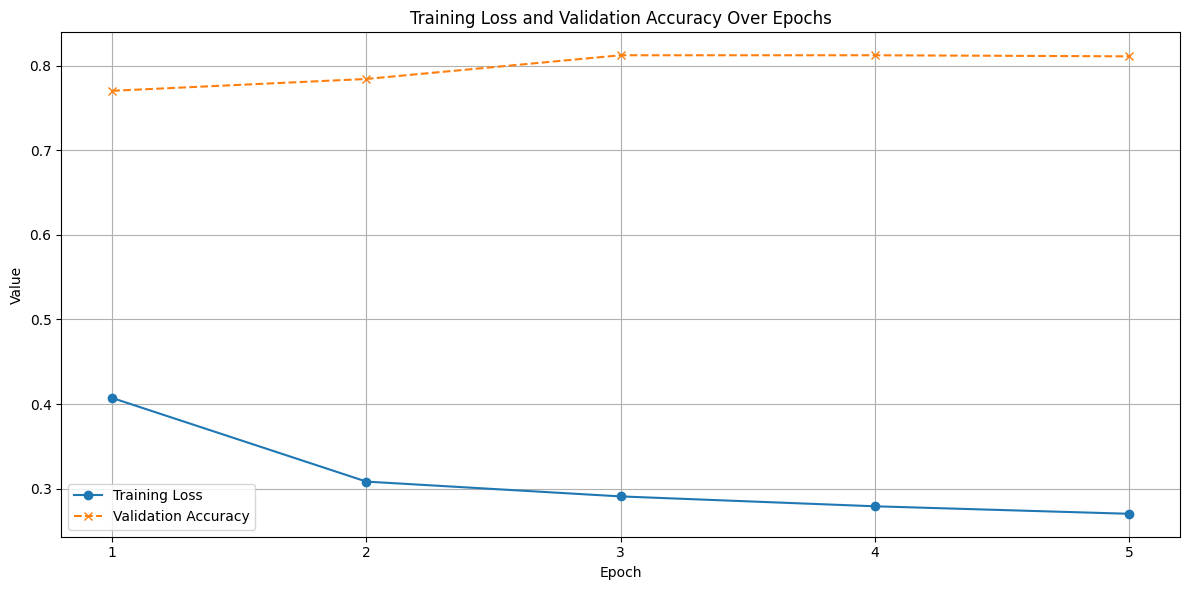


Uncertainty Profiles (Mean Dirichlet Strength S):
  Positive: 6.8845
  Hard negative: 5.6021
  Easy negative: 10.0062
  Ood: 2.0037


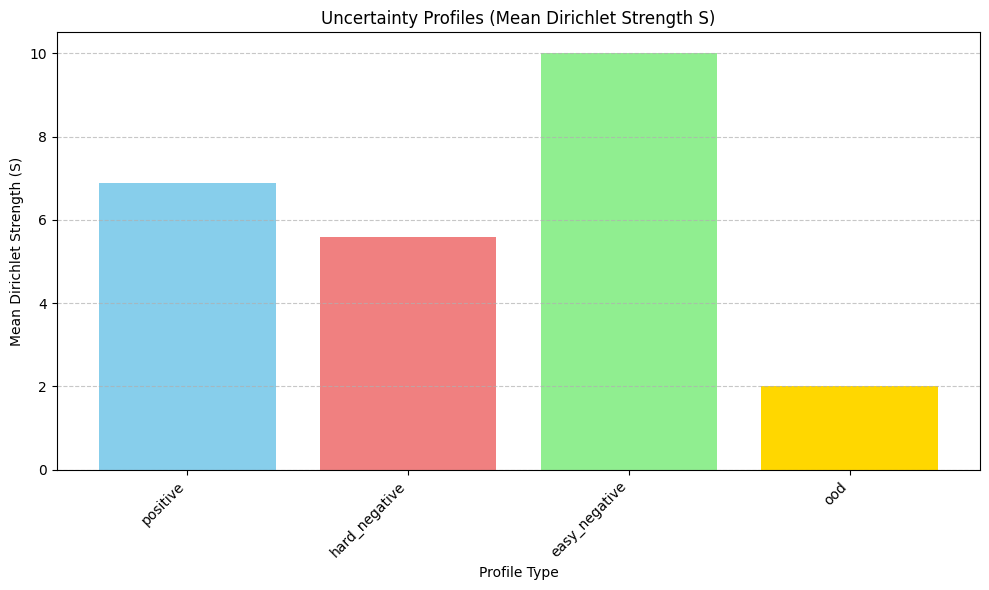

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path # Add this import to ensure Path is available

def visualize_phase2_results(reports_dir_path):
    """
    Loads data from 'reports/phase2/phase2_results.json' and visualizes it
    using matplotlib, showing both scalar metrics and a bar chart of
    uncertainty profiles.
    """
    # 3. Construct the full file path
    results_path = reports_dir_path / 'phase2_results.json'

    # 4. Open the JSON file and load its content
    try:
        with open(results_path, 'r') as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {results_path} was not found. Please ensure it exists.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {results_path}. The file might be corrupted or empty.")
        return

    print("-- Phase 2 Results --")

    # 5. Print scalar metrics
    if 'train_losses' and 'val_accs' in results:
        print("\nScalar Metrics:")
        for metric in ['train_losses', 'val_accs']:
            # Check if value is a list (like train_losses, val_accs, epoch_times) and print the last element
            value = results[metric]
            if isinstance(value, list) and len(value) > 0:
                print(f"  {metric}: {value[-1]:.4f}")
            else:
                print(f"  {metric}: {value}")

        # --- New code for line plots (Scalar Metrics) ---
        train_losses = results.get('train_losses', [])
        val_accs = results.get('val_accs', [])
        epochs = range(1, len(train_losses) + 1)

        if epochs and train_losses and val_accs:
            plt.figure(figsize=(12, 6))
            plt.plot(epochs, train_losses, label='Training Loss', marker='o', linestyle='-')
            plt.plot(epochs, val_accs, label='Validation Accuracy', marker='x', linestyle='--')
            plt.title('Training Loss and Validation Accuracy Over Epochs')
            plt.xlabel('Epoch')
            plt.ylabel('Value')
            plt.xticks(epochs) # Ensure x-axis ticks are integer epochs
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("  Not enough data to plot Training Loss and Validation Accuracy.")

    else:
        print("\nNo scalar metrics found.")

    # 6. Print a header for the uncertainty profiles
    print("\nUncertainty Profiles (Mean Dirichlet Strength S):")

    # 7. Extract the uncertainty_profiles dictionary
    if 'uncertainty_profiles' in results and results['uncertainty_profiles']:
        uncertainty_profiles = results['uncertainty_profiles']

        # Print the uncertainty profiles in a readable format
        for profile_type, value in uncertainty_profiles.items():
            print(f"  {profile_type.replace('_', ' ').capitalize()}: {value:.4f}")

        # 8. Create a bar chart
        profile_types = list(uncertainty_profiles.keys())
        s_values = list(uncertainty_profiles.values())

        plt.figure(figsize=(10, 6))
        plt.bar(profile_types, s_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])

        # 9. Add a title to the bar chart
        plt.title('Uncertainty Profiles (Mean Dirichlet Strength S)')

        # 10. Label the x-axis and y-axis
        plt.xlabel('Profile Type')
        plt.ylabel('Mean Dirichlet Strength (S)')

        # 11. Rotate the x-axis labels if necessary for readability
        plt.xticks(rotation=45, ha='right')

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # 12. Display the plot
        plt.show()
    else:
        print("  No uncertainty profiles found.")


# Re-define PROJECT_ROOT and REPORTS_DIR to ensure they are available in this cell's scope
PROJECT_ROOT = Path('/content/drive/MyDrive/EpistemicRanker') # Use the value from kernel state
REPORTS_DIR  = PROJECT_ROOT / 'reports' / 'phase2'
REPORTS_DIR.mkdir(parents=True, exist_ok=True) # Ensure the directory exists if not already

# Call the function to visualize the results
visualize_phase2_results(REPORTS_DIR)
